# Performance Attribution #

In [1]:
# Import Libraries

# Data Management
import pandas as pd

# Plots
import matplotlib.pyplot as plt

# Handle Files
import sys
import os

# Import Local Functions
sys.path.append(os.path.abspath("../source"))
from data_downloader import get_market_data

In [2]:
# We can download the premiums in the Fama and French website
premiums_df = pd.read_csv(r'../additional_data/ff_size_n_value.csv')
premiums_df.set_index('date', inplace=True)
premiums_df.index = pd.to_datetime(premiums_df.index)
premiums_df.columns = ['mkt_premium', 'smb_premium', 'hml_premium']

# We can download the premiums in the Fama and French website
momemtum_df = pd.read_csv(r'../additional_data/ff_momentum.csv')
momemtum_df.set_index('date', inplace=True)
momemtum_df.index = pd.to_datetime(momemtum_df.index)
momemtum_df.columns = ['wml_premium']

# Create the new Column
premiums_df['wml_premium'] = momemtum_df['wml_premium']
premiums_df = premiums_df.loc['1999-01-05':]

premiums_df

,mkt_premium,smb_premium,hml_premium,wml_premium
date,,,,
1999-01-05,0.0110,-0.0074,-0.0007,-0.0096
1999-01-06,0.0211,-0.0058,-0.0059,-0.0111
1999-01-07,-0.0007,0.0050,-0.0030,-0.0073
1999-01-08,0.0045,0.0009,0.0027,-0.0017
1999-01-11,-0.0052,0.0125,-0.0027,-0.0008
...,...,...,...,...
2024-12-24,0.0111,-0.0009,-0.0006,0.0067
2024-12-26,0.0001,0.0104,-0.0019,0.0000
2024-12-27,-0.0117,-0.0065,0.0057,-0.0085


In [3]:
# And we can import the betas
ff_betas = pd.read_csv(r'../additional_data/ff_coefficients.csv')
ff_betas.rename(columns={'Unnamed: 0': 'stocks'}, inplace=True)
ff_betas.set_index('stocks', inplace=True)

ff_betas

,mkt_beta,smb_beta,hml_beta,wml_beta
stocks,,,,
A,1.128971,0.207682,-0.257203,-0.099570
AAL,1.325925,0.726714,0.761726,-0.440680
AAP,0.795798,0.324448,0.220186,-0.050758
AAPL,1.150409,-0.149558,-0.453476,0.034337
ABBV,0.653552,-0.264476,0.110161,0.068886
...,...,...,...,...
YUM,0.782385,-0.074496,0.143775,0.038774
ZBH,0.767193,0.112810,0.098739,-0.097623
ZBRA,1.069888,0.527373,-0.183733,-0.124856


### Fama and French Attribution ###

In [4]:
# Import Stock Data
ticker = 'MSFT'

# Import Data
data_stock = get_market_data(
    ticker=ticker, 
    start_date='2000-01-01', 
    end_date='2025-01-01', 
    returns=True
)

data_stock

Price,close,high,low,open,volume,returns
Date,,,,,,
2000-01-04,34.398819,35.773245,34.284284,34.685158,54119000,-0.034364
2000-01-05,34.761520,35.544180,33.406184,33.940683,64059600,0.010489
2000-01-06,33.597084,34.780618,33.100763,34.265208,54976600,-0.034072
2000-01-07,34.036137,34.284297,32.776246,33.177120,62013600,0.012984
2000-01-10,34.284286,34.723339,34.017037,34.646982,44963600,0.007264
...,...,...,...,...,...,...
2024-12-24,436.112854,436.380896,431.010509,431.467132,7164500,0.009330
2024-12-26,434.901825,437.711119,433.432682,435.864723,8194200,-0.002781
2024-12-27,427.377319,432.032978,423.227936,431.417523,18117700,-0.017453


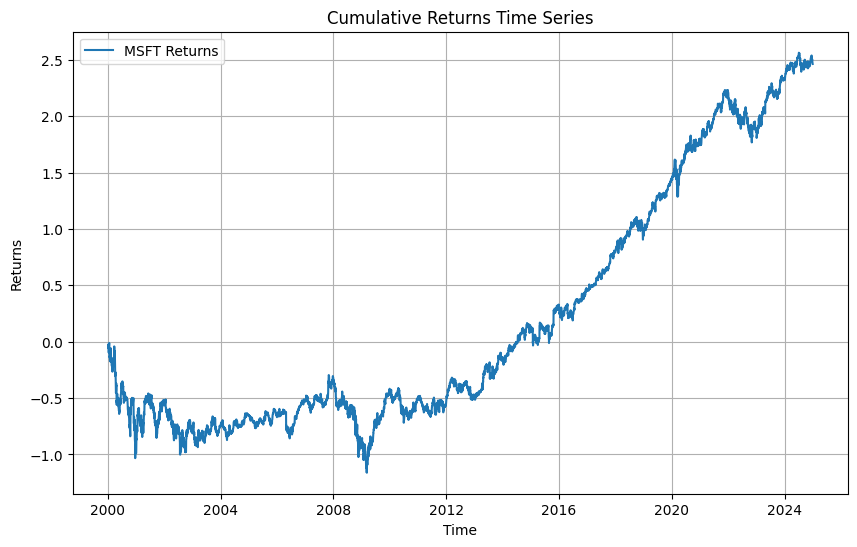

In [5]:
# Create Plot
plt.figure(figsize=(10, 6))
plt.plot(data_stock['returns'].cumsum(), label=f'{ticker} Returns', alpha=1)

# Config
plt.title('Cumulative Returns Time Series')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.legend()
plt.grid()

# Show
plt.show()

In [6]:
# Now let us calculate the returns according to the beta
mkt_contribution = ff_betas.loc[ticker]['mkt_beta'] * premiums_df['mkt_premium']
mkt_contribution.name = 'mkt_contribution'

# For Size
size_contribution = ff_betas.loc[ticker]['smb_beta'] * premiums_df['smb_premium']
size_contribution.name = 'size_contribution'

# For Value
value_contribution = ff_betas.loc[ticker]['hml_beta'] * premiums_df['hml_premium']
value_contribution.name = 'value_contribution'

In [7]:
# And to calculate the residuals, we just have to take the difference
residual_returns = data_stock['returns'] - (mkt_contribution + size_contribution + value_contribution)

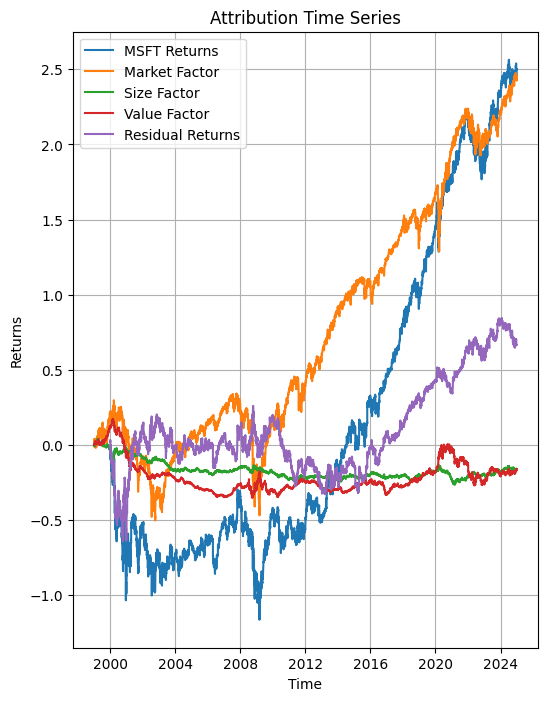

In [8]:
# Create Plot
plt.figure(figsize=(6, 8))
plt.plot(data_stock['returns'].cumsum(), label=f'{ticker} Returns', alpha=1)
plt.plot(mkt_contribution.cumsum(), label='Market Factor', alpha=1)
plt.plot(size_contribution.cumsum(), label='Size Factor', alpha=1)
plt.plot(value_contribution.cumsum(), label='Value Factor', alpha=1)
plt.plot(residual_returns.cumsum(), label='Residual Returns', alpha=1)

# Config
plt.title('Attribution Time Series')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.legend()
plt.grid()

# Save
plt.savefig(r"..\plots\attribution.jpg", dpi=300, bbox_inches="tight")

# Show
plt.show() 

### Returns Contribution ###

In [9]:
# Calculate the mean contributions
mkt__mean_contribution = mkt_contribution.mean() 
size_mean_contribution = size_contribution.mean()
value_mean_contribution = value_contribution.mean()
total_mean_returns = data_stock['returns'].mean()
residual_mean_contribution = data_stock['returns'].mean() - mkt__mean_contribution - size_mean_contribution - value_mean_contribution

print(f'Market Mean Contribution: {mkt__mean_contribution * 25200}')
print(f'Size Mean Contribution: {size_mean_contribution * 25200}')
print(f'Value Mean Contribution: {value_mean_contribution * 25200}')
print(f'Residual Mean Contribution: {residual_mean_contribution * 25200}')

Market Mean Contribution: 9.355107209697012
Size Mean Contribution: -0.6126827845000099
Value Mean Contribution: -0.6459159305572502
Residual Mean Contribution: 1.778637166991492


In [10]:
# Calculate percentages
pct_res = residual_mean_contribution / total_mean_returns * 100
pct_mkt = mkt__mean_contribution / total_mean_returns * 100
pct_smb = size_mean_contribution / total_mean_returns * 100
pct_hml = value_mean_contribution / total_mean_returns * 100

print("Returns Attribution (%)")
print(f"Residuals: {pct_res:.2f}%")
print(f"Market: {pct_mkt:.2f}%")
print(f"SMB: {pct_smb:.2f}%")
print(f"HML: {pct_hml:.2f}%")

Returns Attribution (%)
Residuals: 18.01%
Market: 94.73%
SMB: -6.20%
HML: -6.54%
